In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [7]:
import os

base_path = "/kaggle/input/datasets/akhiljethwa/forest-vs-desert"

for root, dirs, files in os.walk(base_path):
    level = root.replace(base_path, "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        subindent = " " * 2 * (level + 1)
        for f in files[:3]:
            print(f"{subindent}{f}")

forest-vs-desert/
  Data/
    Desert/
    Forest/


In [8]:
import os

base_path = "/kaggle/input/datasets/akhiljethwa/forest-vs-desert/Data"

for cls in ["Forest", "Desert"]:
    cls_path = os.path.join(base_path, cls)
    count = len([f for f in os.listdir(cls_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))])
    print(f"{cls}: {count} images")

Forest: 401 images
Desert: 401 images


In [9]:
# ==========================================================
# Forest vs Desert — Custom Data Pipeline, Shallow CNN,
# and Transfer Learning (Kaggle GPU T4 x2)
# ==========================================================
# !pip install -q albumentations

import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

import albumentations as A
from albumentations.pytorch import ToTensorV2

from torchvision import models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))

# ----------------------------------------------------------
# 1. Build train/val split from the flat Forest/ and Desert/ folders
# ----------------------------------------------------------
BASE_PATH = "/kaggle/input/datasets/akhiljethwa/forest-vs-desert/Data"
CLASSES = ["Forest", "Desert"]
VAL_FRACTION = 0.2  # 20% held out for validation


def build_train_val_split():
    """Returns two lists: train_samples and val_samples, each a list of (filepath, label)."""
    train_samples = []
    val_samples = []

    for label_idx, class_name in enumerate(CLASSES):
        class_dir = os.path.join(BASE_PATH, class_name)
        filenames = sorted([f for f in os.listdir(class_dir) if f.lower().endswith((".png", ".jpg", ".jpeg"))])

        # Shuffle deterministically (same seed every run) before splitting
        rng = random.Random(SEED)
        rng.shuffle(filenames)

        n_val = int(len(filenames) * VAL_FRACTION)
        val_filenames = filenames[:n_val]
        train_filenames = filenames[n_val:]

        for fname in train_filenames:
            train_samples.append((os.path.join(class_dir, fname), label_idx))
        for fname in val_filenames:
            val_samples.append((os.path.join(class_dir, fname), label_idx))

    return train_samples, val_samples


train_samples, val_samples = build_train_val_split()
print("Total train samples:", len(train_samples))
print("Total val samples:", len(val_samples))


class ImageListDataset(Dataset):
    """Custom Dataset that takes a pre-built list of (filepath, label) pairs."""

    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filepath, label = self.samples[idx]
        image = Image.open(filepath).convert("RGB")
        image = np.array(image)

        if self.transform is not None:
            augmented = self.transform(image=image)
            image = augmented["image"]

        return image, label


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
    val_loss = running_loss / len(loader.dataset)
    val_acc = correct / len(loader.dataset)
    return val_loss, val_acc


def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(history["train_loss"], label="train loss")
    axes[0].plot(history["val_loss"], label="val loss")
    axes[0].set_title(title + " — Loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(history["val_acc"], label="val accuracy", color="green")
    axes[1].set_title(title + " — Validation Accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylim(0, 1)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# ==========================================================
# PART A: Shallow CNN transforms and datasets (64x64)
# ==========================================================
IMG_SIZE_SCRATCH = 64

scratch_train_transform = A.Compose([
    A.Resize(IMG_SIZE_SCRATCH + 16, IMG_SIZE_SCRATCH + 16),
    A.RandomCrop(IMG_SIZE_SCRATCH, IMG_SIZE_SCRATCH),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05, p=0.5),
    A.GaussNoise(std_range=(0.02, 0.08), p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

scratch_val_transform = A.Compose([
    A.Resize(IMG_SIZE_SCRATCH, IMG_SIZE_SCRATCH),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

scratch_train_dataset = ImageListDataset(train_samples, transform=scratch_train_transform)
scratch_val_dataset = ImageListDataset(val_samples, transform=scratch_val_transform)

print("Scratch CNN — Train samples:", len(scratch_train_dataset), "| Val samples:", len(scratch_val_dataset))

BATCH_SIZE = 32
scratch_train_loader = DataLoader(scratch_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
scratch_val_loader = DataLoader(scratch_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# ==========================================================
# PART B: Transfer learning transforms and datasets (224x224)
# ==========================================================
IMG_SIZE_TRANSFER = 224

transfer_train_transform = A.Compose([
    A.Resize(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER),
    A.HorizontalFlip(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1, p=0.5),
    A.GaussNoise(std_range=(0.02, 0.08), p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

transfer_val_transform = A.Compose([
    A.Resize(IMG_SIZE_TRANSFER, IMG_SIZE_TRANSFER),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

transfer_train_dataset = ImageListDataset(train_samples, transform=transfer_train_transform)
transfer_val_dataset = ImageListDataset(val_samples, transform=transfer_val_transform)

print("Transfer learning — Train samples:", len(transfer_train_dataset), "| Val samples:", len(transfer_val_dataset))

transfer_train_loader = DataLoader(transfer_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
transfer_val_loader = DataLoader(transfer_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("\nSetup complete. Check the counts above look correct before running Cell 2.")

/usr/local/lib/python3.12/dist-packages/albumentations/check_version.py:147: UserWarning: Error fetching version info <urlopen error [Errno -3] Temporary failure in name resolution>
  data = fetch_version_info()


Using device: cuda
GPU name: Tesla T4
Total train samples: 642
Total val samples: 160
Scratch CNN — Train samples: 642 | Val samples: 160
Transfer learning — Train samples: 642 | Val samples: 160

Setup complete. Check the counts above look correct before running Cell 2.


ShallowCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=1)
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear

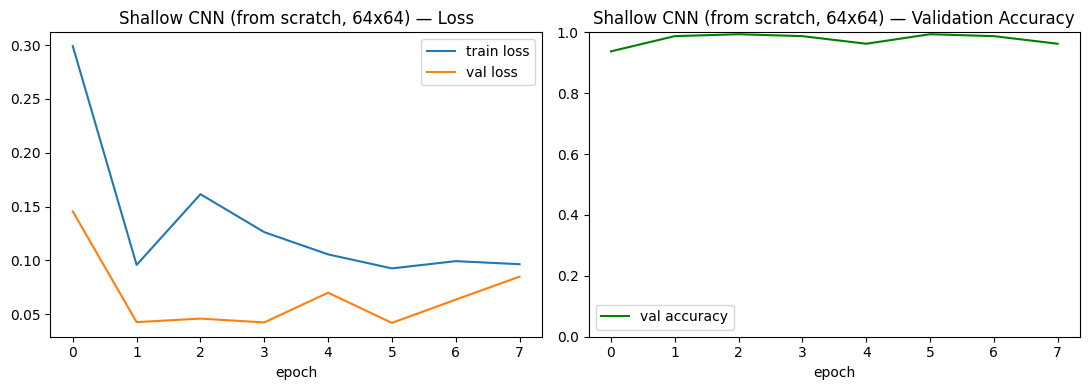

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 205MB/s]

Trainable parameters: 1026


Epoch 1 / 10 | train_loss= 0.4568 | val_loss= 0.2807 | val_acc= 0.9313
Epoch 2 / 10 | train_loss= 0.2821 | val_loss= 0.1722 | val_acc= 0.9625
Epoch 3 / 10 | train_loss= 0.224 | val_loss= 0.196 | val_acc= 0.9437
Epoch 4 / 10 | train_loss= 0.1803 | val_loss= 0.1154 | val_acc= 0.9812
Epoch 5 / 10 | train_loss= 0.1868 | val_loss= 0.1007 | val_acc= 0.9812
Epoch 6 / 10 | train_loss= 0.1368 | val_loss= 0.0942 | val_acc= 0.9688
Epoch 7 / 10 | train_loss= 0.1297 | val_loss= 0.0813 | val_acc= 0.9812
Epoch 8 / 10 | train_loss= 0.0937 | val_loss= 0.0755 | val_acc= 0.9812
Epoch 9 / 10 | train_loss= 0.1046 | val_loss= 0.0755 | val_acc= 0.9875
Epoch 10 / 10 | train_loss= 0.1022 | val_loss= 0.0757 | val_acc= 0.975


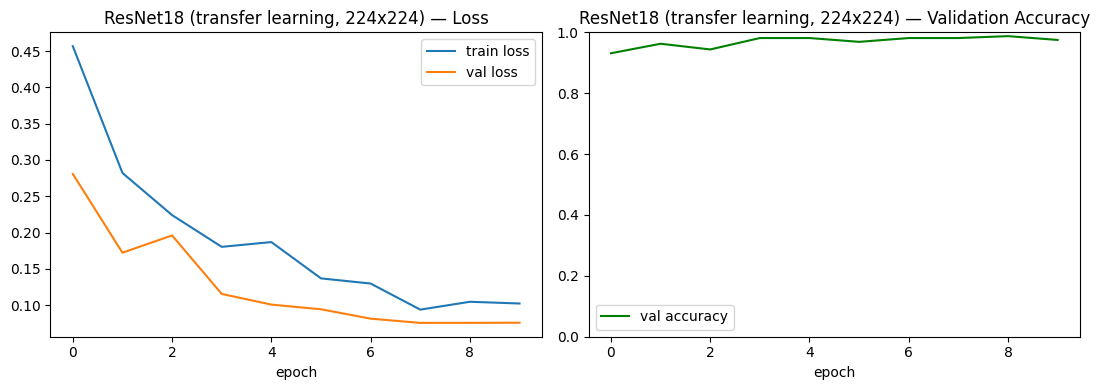

========== Model Comparison ==========
Scratch CNN best val acc:       0.9938
Transfer learning best val acc: 0.9875


In [11]:
# ==========================================================
# PART A: Train the shallow CNN from scratch
# ==========================================================
class ShallowCNN(nn.Module):
    """Custom CNN with BatchNorm (stability) and AdaptiveAvgPool (flexible input size)."""

    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


scratch_model = ShallowCNN(num_classes=len(CLASSES)).to(device)
print(scratch_model)

EPOCHS_SCRATCH = 8
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(scratch_model.parameters(), lr=1e-3)

scratch_history = {"train_loss": [], "val_loss": [], "val_acc": []}
for epoch in range(1, EPOCHS_SCRATCH + 1):
    train_loss = train_one_epoch(scratch_model, scratch_train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(scratch_model, scratch_val_loader, criterion)
    scratch_history["train_loss"].append(train_loss)
    scratch_history["val_loss"].append(val_loss)
    scratch_history["val_acc"].append(val_acc)
    print("Epoch", epoch, "/", EPOCHS_SCRATCH,
          "| train_loss=", round(train_loss, 4),
          "| val_loss=", round(val_loss, 4),
          "| val_acc=", round(val_acc, 4))

plot_history(scratch_history, "Shallow CNN (from scratch, 64x64)")

# ==========================================================
# PART B: Train transfer learning model (ResNet18, 224x224)
# ==========================================================
transfer_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in transfer_model.parameters():
    param.requires_grad = False

in_features = transfer_model.fc.in_features
transfer_model.fc = nn.Linear(in_features, len(CLASSES))
transfer_model = transfer_model.to(device)

trainable_params = [p for p in transfer_model.parameters() if p.requires_grad]
print("Trainable parameters:", sum(p.numel() for p in trainable_params))

EPOCHS_TRANSFER = 10
transfer_criterion = nn.CrossEntropyLoss()
transfer_optimizer = optim.Adam(transfer_model.fc.parameters(), lr=1e-3)

transfer_history = {"train_loss": [], "val_loss": [], "val_acc": []}
for epoch in range(1, EPOCHS_TRANSFER + 1):
    train_loss = train_one_epoch(transfer_model, transfer_train_loader, transfer_criterion, transfer_optimizer)
    val_loss, val_acc = evaluate(transfer_model, transfer_val_loader, transfer_criterion)
    transfer_history["train_loss"].append(train_loss)
    transfer_history["val_loss"].append(val_loss)
    transfer_history["val_acc"].append(val_acc)
    print("Epoch", epoch, "/", EPOCHS_TRANSFER,
          "| train_loss=", round(train_loss, 4),
          "| val_loss=", round(val_loss, 4),
          "| val_acc=", round(val_acc, 4))

plot_history(transfer_history, "ResNet18 (transfer learning, 224x224)")

# ==========================================================
# Compare both models
# ==========================================================
best_scratch = max(scratch_history["val_acc"])
best_transfer = max(transfer_history["val_acc"])

print("========== Model Comparison ==========")
print("Scratch CNN best val acc:      ", round(best_scratch, 4))
print("Transfer learning best val acc:", round(best_transfer, 4))

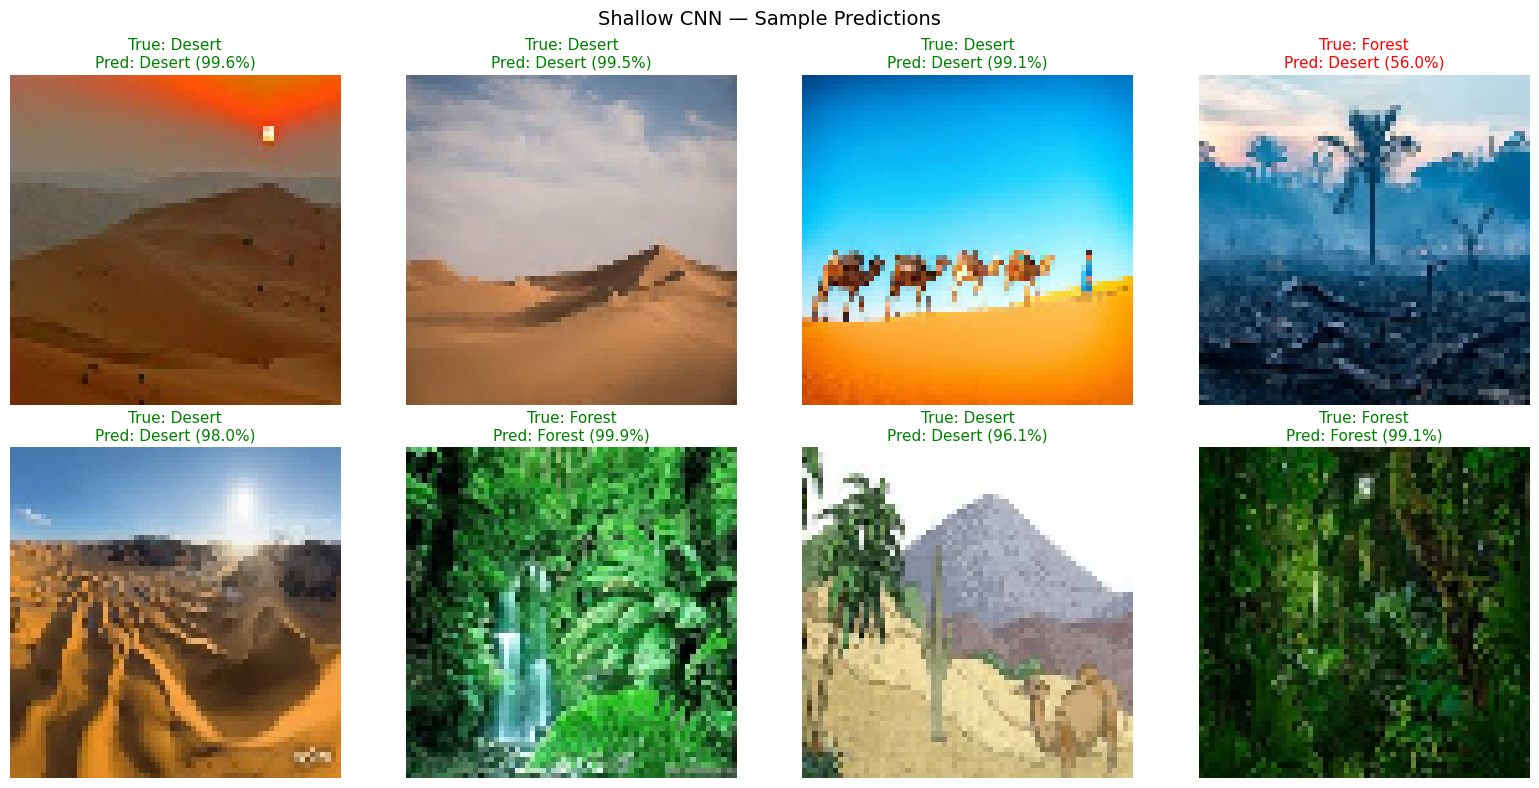

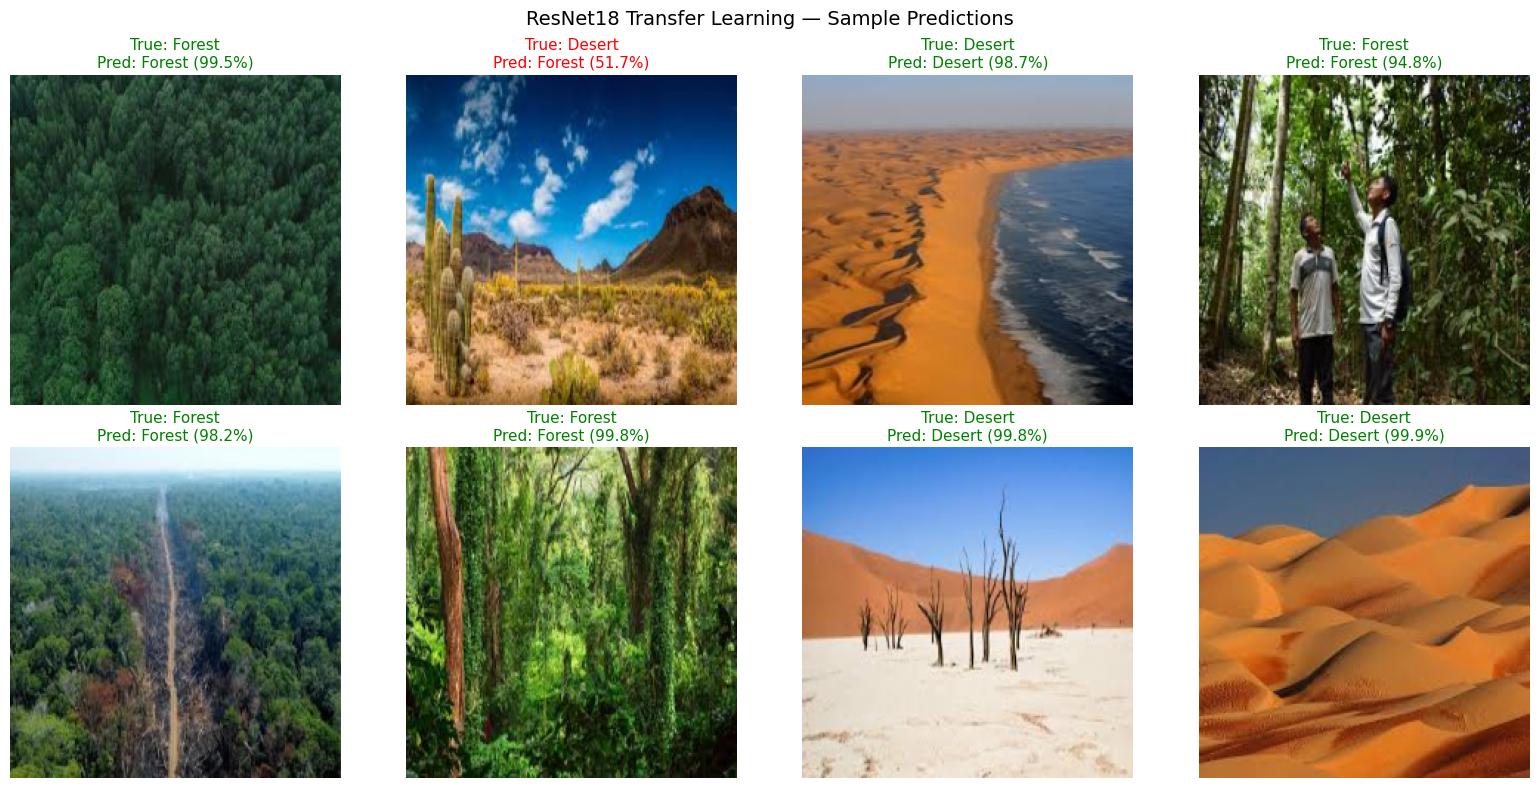

In [12]:
# ==========================================================
# Demo: Test model on sample images from the existing dataset
# ==========================================================
import matplotlib.pyplot as plt
import numpy as np
import torch

def denormalize_for_display(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = (img * std) + mean
    return np.clip(img, 0, 1)


def show_predictions(model, dataset, classes, num_samples=8, title="Model Predictions"):
    model.eval()
    indices = np.random.choice(len(dataset), size=num_samples, replace=False)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    for ax, idx in zip(axes, indices):
        image, true_label = dataset[idx]
        input_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probs = torch.softmax(output, dim=1)
            confidence, pred_label = torch.max(probs, dim=1)

        pred_label = pred_label.item()
        confidence = confidence.item()
        is_correct = (pred_label == true_label)

        ax.imshow(denormalize_for_display(image))
        color = "green" if is_correct else "red"
        ax.set_title(
            f"True: {classes[true_label]}\nPred: {classes[pred_label]} ({confidence*100:.1f}%)",
            color=color, fontsize=11
        )
        ax.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


# Test both models on sample images from the validation set
show_predictions(scratch_model, scratch_val_dataset, CLASSES, num_samples=8,
                  title="Shallow CNN — Sample Predictions")

show_predictions(transfer_model, transfer_val_dataset, CLASSES, num_samples=8,
                  title="ResNet18 Transfer Learning — Sample Predictions")